### Settings

In [2]:
COLAB = True
upload_weights = True
weights_to_upload = ['small']

In [3]:
import os
import shutil

In [4]:
def ignored_files(src, names):
    ignored = []
    for name in names:
        if ".pth" in name and all(size not in name for size in weights_to_upload):
            ignored.append(name) 
    return ignored


google_drive_path = "./drive/MyDrive/LLM_from_scratch/"

if COLAB:
    from google.colab import drive
    
    if os.path.exists("/content/drive"):
        print("Google Drive has already mounted.")
    else:        
        drive.mount('/content/drive')
        print("Google Drive is mounted")

    # ignore_pat = shutil.ignore_patterns('gpt2-large-*.pth') if not upload_weights else None
    shutil.copytree(google_drive_path, "./", ignore=ignored_files, dirs_exist_ok=True)
    print('Files are copied to a Colab server!')
else:
    print("Running locally, not mounting Google Drive.")

Mounted at /content/drive
Google Drive is mounted
Files are copied to a Colab server!


In [5]:
import torch
import torch.nn as nn
import tiktoken

import previous_chapters as prv

### 6.2 Preparing the dataset

In [6]:
# Download `SMSSpamCollection` dataset to the local

import io
import requests
import zipfile

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
destination_path = '../../data/'
filename = 'SMSSpamCollection'

if not COLAB and not os.path.exists(destination_path + filename + '.tsv'):
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(destination_path)

    shutil.move(destination_path + filename, destination_path + filename + '.tsv')
    print('SMSSpamCollection file is successfully downloaded and unzipped')


In [7]:
import pandas as pd

filepath = 'SMSSpamCollection.tsv' if COLAB else '../../data/SMSSpamCollection.tsv'

df = pd.read_csv(filepath, sep='\t', names=['Label', 'Text'])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
pd.concat([df['Label'].value_counts(),
           df['Label'].value_counts(normalize=True)], axis=1)
           

,count,proportion
Label,,
ham,4825,0.865937
spam,747,0.134063


In [9]:
spam_ = df[df["Label"] == 'spam']
ham_sample = df[df["Label"] == 'ham'].sample(n=len(spam_), random_state=123)

df_b = pd.concat([spam_, ham_sample])

df_b["Label"].value_counts()

,count
Label,
spam,747
ham,747


In [10]:
df_b['Label'] = (df_b['Label'] == 'spam').astype(int)

df_b

,Label,Text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
4707,0,Wow so healthy. Old airport rd lor. Cant thk o...
3293,0,Dear good morning how you feeling dear
1278,0,Dont put your phone on silent mode ok
4079,0,Gam gone after outstanding innings.


In [11]:
# Train-test-validation split
def random_split(df, train_frac, validation_frac):
    
    df = df.sample(frac=1, random_state=123)
    train_idx = int(len(df) * train_frac)
    val_idx = int(len(df) * validation_frac)

    df_train = df[:train_idx]
    df_val = df[train_idx: train_idx + val_idx]
    df_test = df[train_idx + val_idx:]

    return df_train, df_val, df_test

In [12]:
train_df, validation_df, test_df = random_split(df_b, 0.7, 0.1) 

len(train_df), len(validation_df), len(test_df)

(1045, 149, 300)

In [13]:
# Saving train, validation, and test datasets as CSV files

path = '' if COLAB else '../../data/'

train_df.to_csv(path + "train.csv", index=None)
validation_df.to_csv(path + "validation.csv", index=None)
test_df.to_csv(path + "test.csv", index=None)

### 6.3 Creating data loaders

In [14]:
from torch.utils.data import Dataset, DataLoader

In [15]:
tokenizer = tiktoken.get_encoding('gpt2')

In [16]:
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

[50256]

In [17]:
class SpamDataset(Dataset):
    def __init__(self,
                 csv_file,
                 tokenizer,
                 max_length=None,
                 pad_token_id=50256):
        
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['Text']]
        
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            # Truncate sequences if they are longer than max_length
            self.max_length = max_length
            self.encoded_texts = [
                enc_text[:self.max_length] for enc_text in self.encoded_texts]
        
        # Pad sequences to the longest sequence
        self.encoded_texts = [
            enc_text + [pad_token_id] * (self.max_length - len(enc_text)) 
                for enc_text in self.encoded_texts]
        
    
    def __getitem__(self, index):
        text = self.encoded_texts[index]
        label = self.data.iloc[index]['Label']

        return torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long)
    
    
    def __len__(self):
        return len(self.data)
    

    def _longest_encoded_length(self):
        return max(len(enc_text) for enc_text in self.encoded_texts)        

In [18]:
path = '' if COLAB else '../../data/'
path

''

In [19]:
train_dataset = SpamDataset(
    csv_file=path + "train.csv",
    tokenizer=tokenizer,
    max_length=None)

In [20]:
train_dataset.max_length

120

In [21]:
val_dataset = SpamDataset(
    csv_file=path + "validation.csv",
    tokenizer=tokenizer,
    max_length=train_dataset.max_length)

test_dataset = SpamDataset(
    csv_file=path + "test.csv",
    tokenizer=tokenizer,
    max_length=train_dataset.max_length)

In [22]:
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=True
)

In [23]:
for i, (input_batch, target_batch) in enumerate(train_loader, 1):
    print(f'Batch: {i}: ', input_batch.shape, target_batch.shape)


Batch: 1:  torch.Size([8, 120]) torch.Size([8])
Batch: 2:  torch.Size([8, 120]) torch.Size([8])
Batch: 3:  torch.Size([8, 120]) torch.Size([8])
Batch: 4:  torch.Size([8, 120]) torch.Size([8])
Batch: 5:  torch.Size([8, 120]) torch.Size([8])
Batch: 6:  torch.Size([8, 120]) torch.Size([8])
Batch: 7:  torch.Size([8, 120]) torch.Size([8])
Batch: 8:  torch.Size([8, 120]) torch.Size([8])
Batch: 9:  torch.Size([8, 120]) torch.Size([8])
Batch: 10:  torch.Size([8, 120]) torch.Size([8])
Batch: 11:  torch.Size([8, 120]) torch.Size([8])
Batch: 12:  torch.Size([8, 120]) torch.Size([8])
Batch: 13:  torch.Size([8, 120]) torch.Size([8])
Batch: 14:  torch.Size([8, 120]) torch.Size([8])
Batch: 15:  torch.Size([8, 120]) torch.Size([8])
Batch: 16:  torch.Size([8, 120]) torch.Size([8])
Batch: 17:  torch.Size([8, 120]) torch.Size([8])
Batch: 18:  torch.Size([8, 120]) torch.Size([8])
Batch: 19:  torch.Size([8, 120]) torch.Size([8])
Batch: 20:  torch.Size([8, 120]) torch.Size([8])
Batch: 21:  torch.Size([8, 12

In [24]:
input_batch

tensor([[   40, 18548,  2298,   262,  3072,   826,   783,    13,  1345,    82,
          3758,   257,  3275, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [ 7282,   362,   670,   362,  4491,   305, 

In [25]:
target_batch

tensor([0, 1, 0, 1, 1, 1, 1, 1])

In [26]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
18 validation batches
37 test batches


### 6.4 Initializing a model with pretrained weights

In [27]:
BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [28]:
# GPT2 weights 
file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

In [29]:
MODEL = "gpt2-small (124M)"

BASE_CONFIG.update(model_configs[MODEL])
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [31]:
model = prv.GPTModel(BASE_CONFIG)
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [32]:
params = torch.load(file_name, weights_only=True, map_location=device)
model.load_state_dict(params)
model.eval();

In [33]:
text1 = "Every effort moves you"

In [34]:
tocken_ids = prv.generate_text_simple(
    model=model,
    idx = prv.text_to_token_ids(text1, tokenizer=tokenizer).to(device),
    max_new_tokens=15,
    context_size=BASE_CONFIG['context_length']
)

In [35]:
print(prv.token_ids_to_text(tocken_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [36]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

In [37]:
tocken_ids = prv.generate_text_simple(
    model=model,
    idx = prv.text_to_token_ids(text_2, tokenizer=tokenizer).to(device),
    max_new_tokens=15,
    context_size=BASE_CONFIG['context_length']
)

print(prv.token_ids_to_text(tocken_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or


### 6.5 Adding a classification head

In [38]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [39]:
n_classes = 2

for params in model.parameters():
    params.requires_grad = False

model.out_head = nn.Linear(
    in_features=BASE_CONFIG['emb_dim'],
    out_features=n_classes,
    device=device
)

In [40]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [41]:
model.out_head.weight

Parameter containing:
tensor([[-0.0313,  0.0321, -0.0202,  ...,  0.0182,  0.0359,  0.0090],
        [ 0.0285, -0.0294,  0.0099,  ...,  0.0157, -0.0337,  0.0108]],
       device='cuda:0', requires_grad=True)

In [42]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [43]:
# def make_trainable(model, block=None):
#     if block:
#         for params in block.parameters():
#             params.requires_grad = True
#         return None
    
#     for params in model.parameters():
#             params.requires_grad = True

# make_trainable(model, model.trf_blocks[-1])
# make_trainable(model, model.final_norm)

In [44]:
model.trf_blocks[-2].att.W_query.weight.requires_grad

False

In [45]:
model.trf_blocks[-1].att.W_query.weight.requires_grad

True

In [46]:
model.trf_blocks[-1].att.W_query.weight

Parameter containing:
tensor([[-0.2175,  0.0073,  0.1679,  ...,  0.0365, -0.1372,  0.1725],
        [ 0.0608, -0.1360, -0.1013,  ...,  0.1295,  0.1039,  0.0285],
        [-0.0637, -0.0365,  0.0714,  ...,  0.0607,  0.0054, -0.0258],
        ...,
        [ 0.0504, -0.0769, -0.0349,  ..., -0.3092, -0.2252,  0.1219],
        [ 0.0108, -0.0549,  0.1284,  ...,  0.0138, -0.0663, -0.0728],
        [-0.1579,  0.0160, -0.0867,  ...,  0.1783,  0.0072, -0.0060]],
       device='cuda:0', requires_grad=True)

In [47]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
inputs = inputs.to(device)

print(inputs.shape)
inputs

torch.Size([1, 4])


tensor([[5211,  345,  423,  640]], device='cuda:0')

In [48]:
with torch.no_grad():
    out = model(inputs)

print(out.shape)
out

torch.Size([1, 4, 2])


tensor([[[-0.5493,  0.8412],
         [-5.0857,  6.1811],
         [-4.6876,  4.8186],
         [-2.5845,  2.7198]]], device='cuda:0')

In [49]:
# The last output token
out[:,-1,:]

tensor([[-2.5845,  2.7198]], device='cuda:0')

### 6.6 Calculating the classification loss and accuracy

In [50]:
probas = torch.softmax(out[:,-1,:], dim=-1)
class_ = torch.argmax(probas)

probas, class_.item()


(tensor([[0.0049, 0.9951]], device='cuda:0'), 1)

In [ ]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    num_batches = \
        min(num_batches, len(data_loader)) if num_batches else len(data_loader)

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token

            predictions = torch.argmax(logits, dim=-1)
            num_examples += len(input_batch)

            correct_predictions += (predictions == target_batch).sum().item()

        else:
            break

    return correct_predictions / num_examples

In [52]:
device

'cuda'

In [53]:
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10)

val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10)

test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10)


In [54]:
print(f'{train_accuracy=:.2%}')
print(f'{val_accuracy=:.2%}')
print(f'{test_accuracy=:.2%}')

train_accuracy=53.75%
val_accuracy=55.00%
test_accuracy=51.25%


In [55]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    
    logits = model(input_batch)[:, -1, :]
    loss = nn.functional.cross_entropy(logits, target_batch)
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):

    if len(data_loader) == 0:
        return float("nan")
    
    num_batches = \
        min(num_batches, len(data_loader)) if num_batches else len(data_loader)
    
    total_loss = 0
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            total_loss += calc_loss_batch(
                input_batch, target_batch, model, device).item()

        else:
            break

    return total_loss / num_batches

In [56]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

In [57]:
print(f'{train_loss=:.2f}')
print(f'{val_loss=:.2f}')
print(f'{test_loss=:.2f}')

train_loss=4.91
val_loss=4.67
test_loss=5.13


### 6.7 Fine-tuning the model on supervised data

In [58]:
import matplotlib.pyplot as plt

In [59]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

    model.train()

    return train_loss, val_loss


def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs, eval_freq, eval_iter):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # Reset loss gradients from previous batch iteration

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()     # Calculate loss gradients
            optimizer.step()    # Update model weights using loss gradients

            examples_seen += len(input_batch)
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = \
                    evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Training accuracy: {train_accuracy:.2%} | ", end="")
        print(f"Validation accuracy: {val_accuracy:.2%}")

    
    return train_losses, val_losses, train_accs, val_accs, examples_seen


In [60]:
device

'cuda'

In [61]:
%%time

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs,
        eval_freq=50,
        eval_iter=5)

Ep 1 (Step 000000): Train loss 4.967, Val loss 4.521
Ep 1 (Step 000050): Train loss 0.717, Val loss 0.718
Ep 1 (Step 000100): Train loss 0.682, Val loss 0.655
Training accuracy: 52.50% | Validation accuracy: 50.00%
Ep 2 (Step 000150): Train loss 0.614, Val loss 0.609
Ep 2 (Step 000200): Train loss 0.562, Val loss 0.548
Ep 2 (Step 000250): Train loss 0.475, Val loss 0.471
Training accuracy: 92.50% | Validation accuracy: 82.50%
Ep 3 (Step 000300): Train loss 0.401, Val loss 0.428
Ep 3 (Step 000350): Train loss 0.416, Val loss 0.450
Training accuracy: 90.00% | Validation accuracy: 82.50%
Ep 4 (Step 000400): Train loss 0.285, Val loss 0.367
Ep 4 (Step 000450): Train loss 0.368, Val loss 0.224
Ep 4 (Step 000500): Train loss 0.113, Val loss 0.161
Training accuracy: 92.50% | Validation accuracy: 92.50%
Ep 5 (Step 000550): Train loss 0.163, Val loss 0.123
Ep 5 (Step 000600): Train loss 0.013, Val loss 0.116
Training accuracy: 97.50% | Validation accuracy: 95.00%
CPU times: user 1min 6s, sys: 4

In [62]:
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(6, 4))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

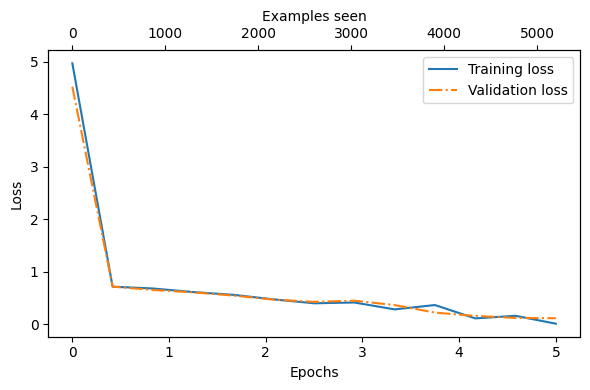

In [63]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses);

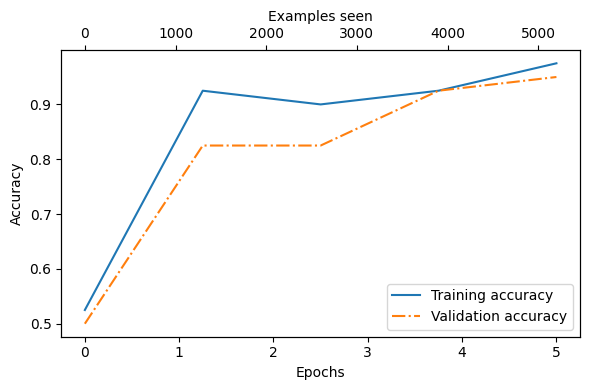

In [64]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy");

In [65]:
%%time

train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

CPU times: user 14.4 s, sys: 6.43 ms, total: 14.4 s
Wall time: 14.5 s


In [66]:

print(f'{train_accuracy=:.2%}')
print(f'{val_accuracy=:.2%}')
print(f'{test_accuracy=:.2%}')

train_accuracy=97.60%
val_accuracy=97.22%
test_accuracy=96.96%


### 6.8 Using the LLM as a spam classifier

In [72]:
model.pos_emb.weight.shape

torch.Size([1024, 768])

In [86]:
def classify_review(
    text, model, tokenizer, device, max_length=None, pad_token_id=50256):

    model.eval()
    
    supported_context_len = model.pos_emb.weight.shape[0]
    max_len = min(supported_context_len, max_length) if max_length else supported_context_len
    
    tocken_ids = tokenizer.encode(text)
    tocken_ids = tocken_ids[:max_len]   # Truncate sequences if they too long
    tocken_ids += [pad_token_id] * (max_len - len(tocken_ids))  # Pad sequences to the longest sequence
    input_tensor = torch.tensor(tocken_ids, device=device).unsqueeze(0)

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:,-1,:]  # Logits of the last output token

    class_preds = torch.argmax(logits, dim=-1).item()

    return 'spam' * class_preds + 'nospam' * (1 - class_preds)
    # return (logits, 'spam' * class_preds + 'nospam' * (1 - class_preds))

In [87]:
train_dataset.max_length

120

In [93]:
# res = []
# for txt in train_dataset.data['Text']:
#     res.append(classify_review(
#         txt, model, tokenizer, device, max_length=train_dataset.max_length)
#         )
    
# res

In [90]:
text_1 = \
 "You are a winner you have been specially selected to receive $1000 cash or a $2000 award."

classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length)

'spam'

In [91]:
text_2 = "Hey, just wanted to check if we're still on for dinner tonight? Let me know!" 

classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length)

'nospam'

In [92]:
text_2 = "'m sorry. I've joined the league of people that dont keep in touch. You mean a great deal to me. You have been a friend at all times even at great personal cost. Do have a great week." 

classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length)

'nospam'